# LAB | Feature Engineering

**Load the data**

In this challenge, we will be working with the same Spaceship Titanic data, like the previous Lab. The data can be found here:

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv

Metadata

https://github.com/data-bootcamp-v4/data/blob/main/spaceship_titanic.md

In [1]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import torch
from torch import optim
import torch.nn as nn

In [2]:
spaceship = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv")
spaceship.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


**Check the shape of your data**

In [3]:
spaceship.shape

(8693, 14)

**Check for data types**

In [4]:
spaceship.dtypes

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

**Check for missing values**

In [5]:
spaceship.isnull().any()

PassengerId     False
HomePlanet       True
CryoSleep        True
Cabin            True
Destination      True
Age              True
VIP              True
RoomService      True
FoodCourt        True
ShoppingMall     True
Spa              True
VRDeck           True
Name             True
Transported     False
dtype: bool

In [6]:
spaceship.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

There are multiple strategies to handle missing data

- Removing all rows or all columns containing missing data.
- Filling all missing values with a value (mean in continouos or mode in categorical for example).
- Filling all missing values with an algorithm.

For this exercise, because we have such low amount of null values, we will drop rows containing any missing value. 

In [7]:
spaceship.dropna(inplace=True)

- **Cabin** is too granular - transform it in order to obtain {'A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'}

In [8]:
list(spaceship['Cabin'].unique())

['B/0/P',
 'F/0/S',
 'A/0/S',
 'F/1/S',
 'F/0/P',
 'F/2/S',
 'F/3/S',
 'B/1/P',
 'F/1/P',
 'G/1/S',
 'F/2/P',
 'F/4/P',
 'F/5/P',
 'G/0/P',
 'F/6/P',
 'E/0/S',
 'F/6/S',
 'C/0/P',
 'F/8/P',
 'G/4/S',
 'F/9/P',
 'D/1/S',
 'D/1/P',
 'F/10/S',
 'G/2/P',
 'B/3/P',
 'G/3/P',
 'F/10/P',
 'E/2/S',
 'F/11/S',
 'A/1/S',
 'G/7/S',
 'F/12/S',
 'F/13/S',
 'G/6/P',
 'G/10/S',
 'F/15/S',
 'F/13/P',
 'F/14/P',
 'F/17/S',
 'D/3/P',
 'C/3/S',
 'F/18/S',
 'F/15/P',
 'C/4/S',
 'G/13/S',
 'F/16/P',
 'G/14/S',
 'C/5/S',
 'F/17/P',
 'E/5/S',
 'G/15/S',
 'F/20/S',
 'G/9/P',
 'A/2/S',
 'G/11/P',
 'F/19/P',
 'F/23/S',
 'G/18/S',
 'D/2/S',
 'G/19/S',
 'B/5/P',
 'E/6/S',
 'B/1/S',
 'F/23/P',
 'G/20/S',
 'D/4/P',
 'A/0/P',
 'G/21/S',
 'F/27/P',
 'F/27/S',
 'E/7/S',
 'D/3/S',
 'E/8/S',
 'F/29/S',
 'D/5/S',
 'G/17/P',
 'G/18/P',
 'C/6/S',
 'G/19/P',
 'F/29/P',
 'F/31/S',
 'G/25/S',
 'G/26/S',
 'F/31/P',
 'G/20/P',
 'G/22/P',
 'B/8/P',
 'G/28/S',
 'F/35/S',
 'G/23/P',
 'E/10/S',
 'G/30/S',
 'G/24/P',
 'F/38/P',
 'B/

In [9]:
spaceship['Cabin'] = spaceship['Cabin'].apply(lambda x: x.split("/")[0])

In [10]:
spaceship['Cabin']

0       B
1       F
2       A
3       A
4       F
       ..
8688    A
8689    G
8690    G
8691    E
8692    E
Name: Cabin, Length: 6606, dtype: object

- Drop PassengerId and Name

In [11]:
spaceship.drop(columns=['PassengerId', 'Name'], inplace=True)

- For non-numerical columns, do dummies.

In [12]:
for column in spaceship.select_dtypes('object'):
    if len(spaceship[column].unique()) > 2:
        dummies = pd.get_dummies(spaceship[column], dtype=int, prefix=column)
    else:
        dummies = pd.get_dummies(spaceship[column], drop_first=True, dtype=int, prefix=column)
    spaceship = pd.concat([spaceship.drop(columns=[column]), dummies], axis=1)

In [13]:
spaceship['Transported'] = spaceship['Transported'].astype(int)

**Perform Train Test Split**

In [14]:
spaceship

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,...,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True
0,39.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
1,24.0,109.0,9.0,25.0,549.0,44.0,1,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,58.0,43.0,3576.0,0.0,6715.0,49.0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1
3,33.0,0.0,1283.0,371.0,3329.0,193.0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,16.0,303.0,70.0,151.0,565.0,2.0,1,1,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,41.0,0.0,6819.0,0.0,1643.0,74.0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
8689,18.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
8690,26.0,0.0,0.0,1872.0,1.0,0.0,1,1,0,0,...,0,0,0,0,1,0,0,0,1,0
8691,32.0,0.0,1049.0,0.0,353.0,3235.0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,0


In [15]:
X = spaceship.drop(columns=['Transported'])

In [16]:
y = spaceship['Transported']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.20)

## Scaling

In [18]:
scaler = StandardScaler()
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [19]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
print(X_train_scaled.shape, X_train_scaled.dtype)
print(X_test_scaled.shape, X_test_scaled.dtype)

(5284, 22) float64
(1322, 22) float64


In [21]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

In [22]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [23]:
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1,1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1,1)

**Neural Network**

In this exercise we will be using a **Neural Network** as our predictive model.

In [24]:
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN, self).__init__()
        self.network = nn.Sequential(nn.Linear(input_size,hidden_size),
                                     nn.ReLU(),
                                    nn.Linear(hidden_size,output_size),
                                    nn.Sigmoid())
    def forward(self, x):
        return self.network(x)

In [25]:
input_size = 22
hidden_size = 12
output_size = 1

model = SimpleNN(input_size, hidden_size, output_size)

In [26]:
# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model
epochs = 1500
for epoch in range(epochs):
    model.train()  # Set the model to training mode

    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [10/1500], Loss: 0.6978
Epoch [20/1500], Loss: 0.6824
Epoch [30/1500], Loss: 0.6685
Epoch [40/1500], Loss: 0.6554
Epoch [50/1500], Loss: 0.6424
Epoch [60/1500], Loss: 0.6291
Epoch [70/1500], Loss: 0.6156
Epoch [80/1500], Loss: 0.6017
Epoch [90/1500], Loss: 0.5878
Epoch [100/1500], Loss: 0.5741
Epoch [110/1500], Loss: 0.5605
Epoch [120/1500], Loss: 0.5474
Epoch [130/1500], Loss: 0.5351
Epoch [140/1500], Loss: 0.5236
Epoch [150/1500], Loss: 0.5130
Epoch [160/1500], Loss: 0.5032
Epoch [170/1500], Loss: 0.4942
Epoch [180/1500], Loss: 0.4860
Epoch [190/1500], Loss: 0.4787
Epoch [200/1500], Loss: 0.4720
Epoch [210/1500], Loss: 0.4660
Epoch [220/1500], Loss: 0.4606
Epoch [230/1500], Loss: 0.4557
Epoch [240/1500], Loss: 0.4514
Epoch [250/1500], Loss: 0.4475
Epoch [260/1500], Loss: 0.4441
Epoch [270/1500], Loss: 0.4411
Epoch [280/1500], Loss: 0.4383
Epoch [290/1500], Loss: 0.4359
Epoch [300/1500], Loss: 0.4336
Epoch [310/1500], Loss: 0.4315
Epoch [320/1500], Loss: 0.4296
Epoch [330/1500],

Test Loss: 0.4013


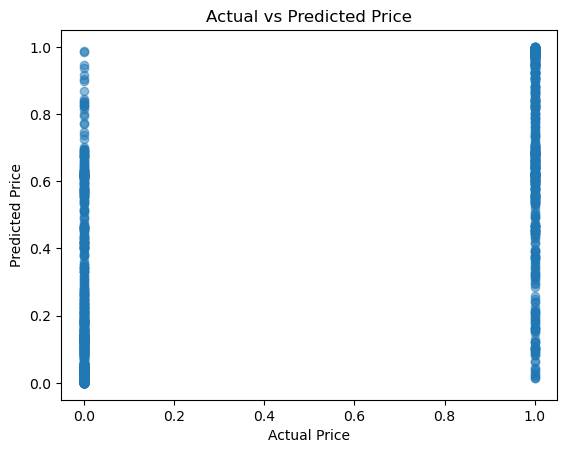

In [95]:
model.eval()  # This sets the model to evaluation mode
with torch.no_grad():
    predictions = model(X_test_tensor)
    test_loss = criterion(predictions, y_test_tensor)
    print(f'Test Loss: {test_loss.item():.4f}')

# Plotting our results
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions.numpy(), alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()

In [27]:
from sklearn.metrics import accuracy_score, recall_score

# Evaluate the model
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    predictions = (model(X_test_tensor) > 0.5).int().numpy()
    actuals = y_test_tensor.numpy()

accuracy = recall_score(actuals, predictions)
print(f'accuracy score: {accuracy:.4f}')

accuracy score: 0.8341
